<a href="https://colab.research.google.com/github/pratyushsingh9870-arch/ML_lab/blob/main/Lab_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving TvMarketing.csv to TvMarketing.csv
First 5 rows:
      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB
None

Statistical Summary:
               TV       Sales
count  200.000000  200.000000
mean   147.042500   14.022500
std     85.854236    5.217457
min      0.700000    1.600000
25%     74.375000   10.375000
50%    149.750000   12.900000
75%    218.825000   17.400000
max    296.400000   27.000000


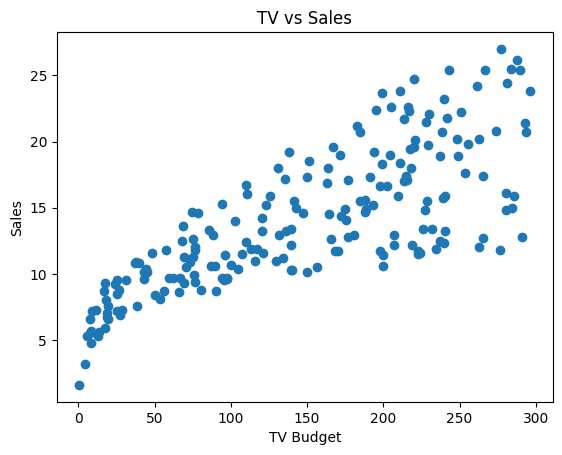

Train Shape: (160, 1)
Test Shape: (40, 1)
Intercept: 7.119638430592953
Slope: 0.046529733705443346


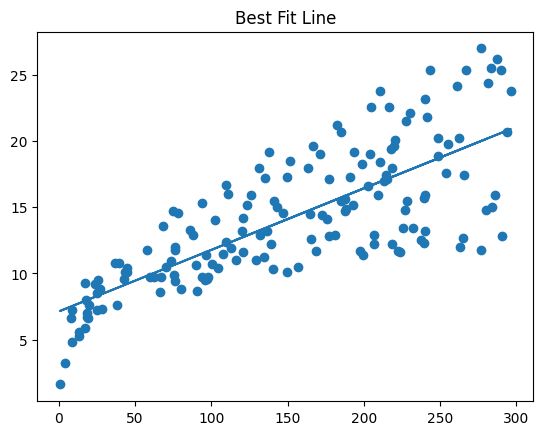

     Actual  Predicted
95     16.9  14.717944
15     22.4  16.211548
30     21.4  20.748197
158     7.3   7.664036
128    24.7  17.370139
RMSE: 3.194472431998898
R2 Score: 0.6766954295627076


KeyError: "None of [Index(['Volume', 'Weight'], dtype='object')] are in the [columns]"

In [1]:
# ============================
# 🔹 STEP 1: Upload Dataset
# ============================
from google.colab import files
uploaded = files.upload()

# ============================
# 🔹 STEP 2: Import Libraries
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# 🔹 STEP 3: Load Dataset
# ============================
# Change filename accordingly after upload
df = pd.read_csv(list(uploaded.keys())[0])

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ============================
# 🔹 EXPERIMENT 1: SIMPLE LINEAR REGRESSION
# ============================

# 👉 CHANGE COLUMN NAMES IF DIFFERENT
X = df[['TV']]      # independent
y = df['Sales']     # dependent

# Visualization
plt.scatter(X, y)
plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.title("TV vs Sales")
plt.show()

# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# Model Training
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Parameters
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

# Best Fit Line
plt.scatter(X_train, y_train)
plt.plot(X_train, model.predict(X_train))
plt.title("Best Fit Line")
plt.show()

# Predictions
y_pred = model.predict(X_test)

# Comparison
comparison = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(comparison.head())

# Metrics
from sklearn.metrics import mean_squared_error, r2_score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)


# ============================
# 🔹 EXPERIMENT 2: MULTIPLE LINEAR REGRESSION
# ============================

# 👉 CHANGE COLUMN NAMES IF DIFFERENT
X = df[['Volume', 'Weight']]
y = df['CO2']

# Correlation Heatmap
corr = df[['Volume','Weight','CO2']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Boxplot (Outliers)
sns.boxplot(data=df[['Volume','Weight','CO2']])
plt.title("Outlier Detection")
plt.show()

# Scatter
plt.scatter(df['Volume'], df['CO2'])
plt.xlabel("Volume")
plt.ylabel("CO2")
plt.show()

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Parameters
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Prediction
y_pred = model.predict(X_test)

# Plot Actual vs Predicted
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

# Metrics
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)


# ============================
# 🔹 EXPERIMENT 3: LOGISTIC REGRESSION
# ============================

# 👉 CHANGE COLUMN NAMES BASED ON YOUR DATASET
# Target must be binary (0/1)

# Example:
# X = df.drop('Clicked on Ad', axis=1)
# y = df['Clicked on Ad']

# Drop non-numeric columns if needed
df = df.select_dtypes(include=np.number)

# Assume last column is target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

# Train Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

# Parameters
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Predictions
y_pred = model.predict(X_test)

# Classification Report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve, auc
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

# K-Fold Cross Validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_scaled, y, cv=5)

print("CV Scores:", scores)
print("Average CV Score:", scores.mean())

# Actual vs Predicted Plot
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()